# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import math

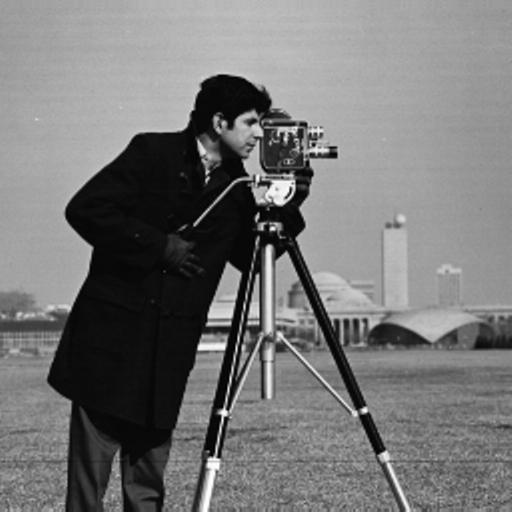

In [6]:
# ── Load image ────────────────────────────────────
img = Image.open("cameraman.jpg")
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [9]:
# Get the size of the image
width, height = img.size

# scaling factors
sx, sy = 2, 2

In [10]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize((width * sx, height * sy), Image.LANCZOS)


In [11]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [12]:
cx, cy = 2, 1

In [13]:
non_uniform = img.resize((width * cx, height * cy), Image.LANCZOS)

In [15]:
non_uniform.save("task1_1_nonuniform.jpg")

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [16]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True)
rotated_img.save("task1_2_rotated.jpg")
print("Rotated size:", rotated_img.size)

Rotated size: (700, 700)


### 3. Shear

In [17]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

In [19]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5  
shy = 0

matrix = (1, shx, 0,
          shy, 1, 0)

In [20]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

sheared_img = img.transform(
    (int(width * 1.5), height),  
    Image.AFFINE,
    matrix,
    resample=Image.BICUBIC
)


In [21]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [22]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
img_np = np.array(img)

negative_np = 255 - img_np

negative_img = Image.fromarray(negative_np.astype('uint8'))
negative_img.save("negative_numpy.jpg")



In [23]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(img)
negative_pil.save("negative_pil.jpg")

In [24]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

# Apply the log transformation to each pixel

img_np = np.array(img)

# normalize
img_float = img_np / 255.0

# constant c
c = 255 / math.log(1 + 255)

log_transformed = c * np.log(1 + img_np)

log_img = np.array(log_transformed, dtype=np.uint8)

log_img = Image.fromarray(log_img)
log_img.save("log_transformed.jpg")

/tmp/ipykernel_4521/1575785160.py:18: RuntimeWarning: divide by zero encountered in log
  log_transformed = c * np.log(1 + img_np)
/tmp/ipykernel_4521/1575785160.py:20: RuntimeWarning: invalid value encountered in cast
  log_img = np.array(log_transformed, dtype=np.uint8)


In [25]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5  

img_np = np.array(img) / 255.0

gamma_corrected = np.power(img_np, gamma)

gamma_img = np.array(gamma_corrected * 255, dtype=np.uint8)

gamma_img = Image.fromarray(gamma_img)
gamma_img.save("gamma_corrected.jpg")